# Faizal Deshta Nugraha
# 2340506065

# 1. Filter Speckle Noise 

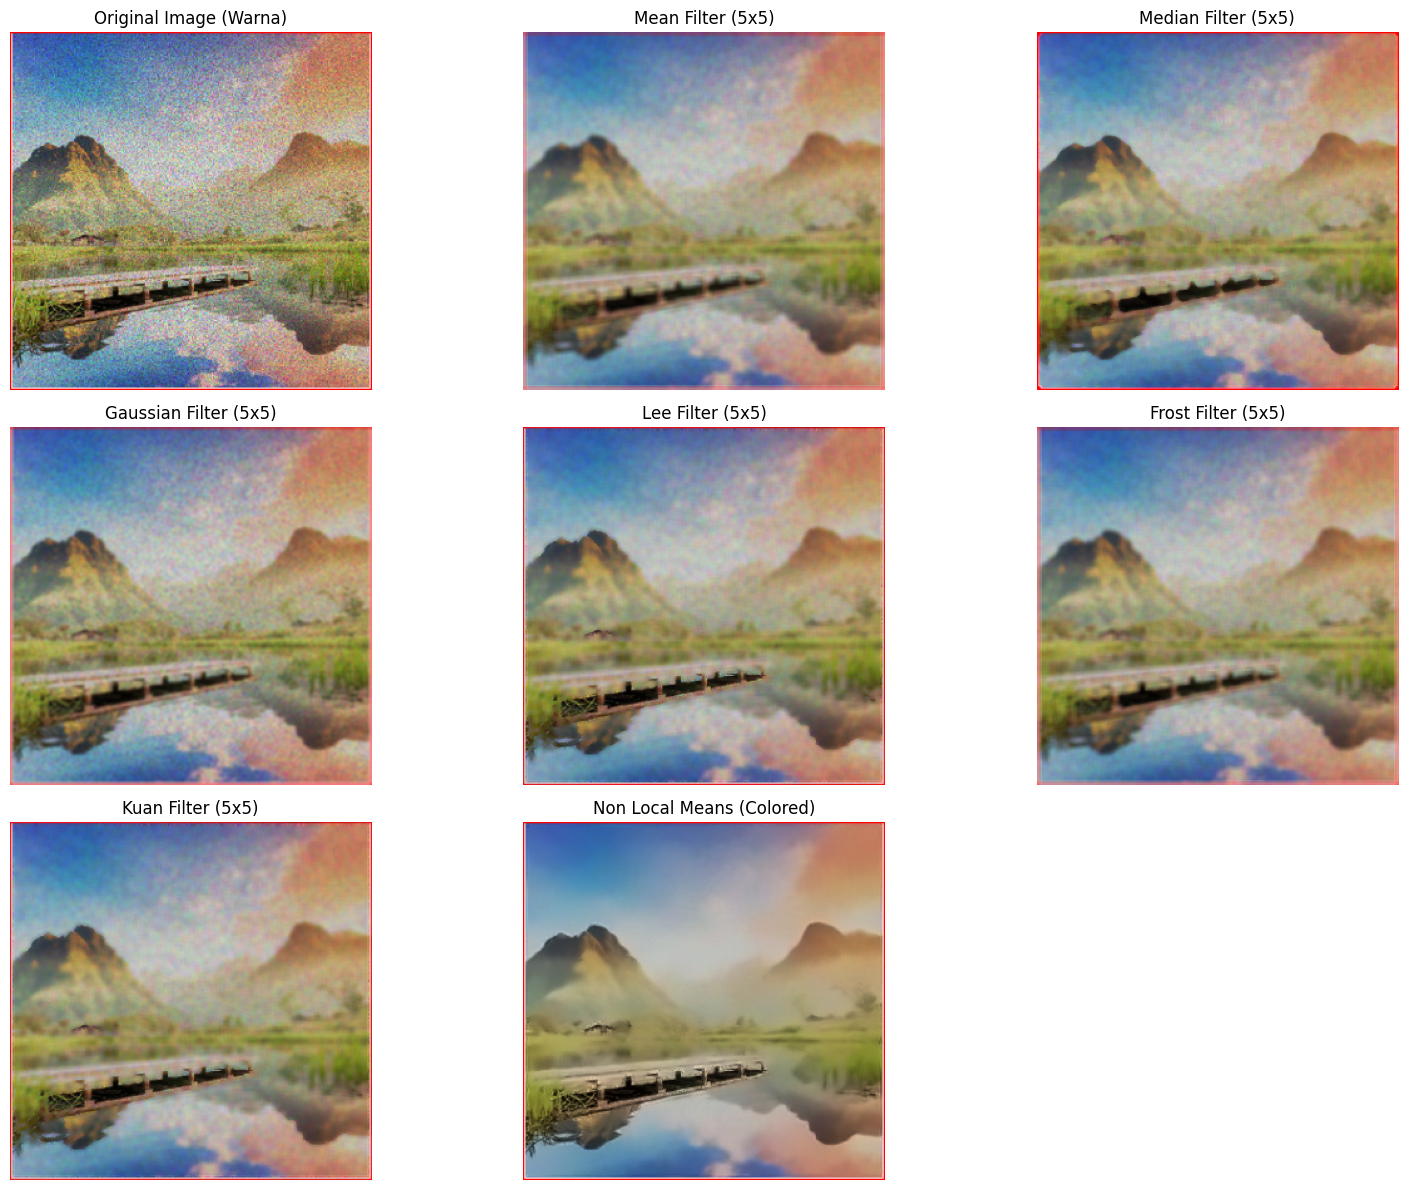

In [59]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1_bgr = cv2.imread("tugas 1.png")
img1_rgb = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)

# Fungsi Filter Speckle 
def lee_filter(img, win_size=5, cu=0.25):
    img_f = img.astype(np.float32)
    mean = cv2.blur(img_f, (win_size, win_size))
    mean_sq = cv2.blur(img_f**2, (win_size, win_size))
    variance = np.maximum(mean_sq - mean**2, 0)
    
    ci = np.sqrt(variance) / (mean + 1e-6)
    weight = np.clip(1.0 - (cu**2) / (ci**2 + 1e-6), 0, 1)
    
    out = mean + weight * (img_f - mean)
    return np.clip(out, 0, 255).astype(np.uint8)

def kuan_filter(img, win_size=5, cu=0.25):
    img_f = img.astype(np.float32)
    mean = cv2.blur(img_f, (win_size, win_size))
    mean_sq = cv2.blur(img_f**2, (win_size, win_size))
    variance = np.maximum(mean_sq - mean**2, 0)
    
    ci = np.sqrt(variance) / (mean + 1e-6)
    weight = (1.0 - (cu**2) / (ci**2 + 1e-6)) / (1.0 + cu**2)
    weight = np.clip(weight, 0, 1)
    
    out = mean + weight * (img_f - mean)
    return np.clip(out, 0, 255).astype(np.uint8)

def frost_filter(img, win_size=5, a=1.0):
    img_f = img.astype(np.float32)
    k = win_size // 2
    y, x = np.mgrid[-k:k+1, -k:k+1]
    dist = np.sqrt(x**2 + y**2).astype(np.float32)
    
    mean = cv2.blur(img_f, (win_size, win_size))
    mean_sq = cv2.blur(img_f**2, (win_size, win_size))
    var = np.maximum(mean_sq - mean**2, 0)
    B = a * (var / (mean**2 + 1e-6))
    
    pad_shape = ((k, k), (k, k), (0, 0)) if img_f.ndim == 3 else ((k, k), (k, k))
    padded = np.pad(img_f, pad_shape, mode='reflect')
    
    num = np.zeros_like(img_f)
    den = np.zeros_like(img_f)
    
    for dy in range(win_size):
        for dx in range(win_size):
            d = dist[dy, dx]
            w_i = np.exp(-B * d)
            patch = padded[dy:dy+img_f.shape[0], dx:dx+img_f.shape[1]]
            num += w_i * patch
            den += w_i
            
    out = num / (den + 1e-6)
    return np.clip(out, 0, 255).astype(np.uint8)

# Filtering Warna (RGB)
mean_filter = cv2.blur(img1_rgb, (5,5))
median_filter = cv2.medianBlur(img1_rgb, 5)
gaussian_filter = cv2.GaussianBlur(img1_rgb, (5,5), 0)
lee_filtered = lee_filter(img1_rgb, win_size=5, cu=0.25)
frost_filtered = frost_filter(img1_rgb, win_size=5, a=1.0)
kuan_filtered = kuan_filter(img1_rgb, win_size=5, cu=0.25)
nlm1_rgb = cv2.fastNlMeansDenoisingColored(img1_rgb, None, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21)

# Plot Hasil (Warna)
plt.figure(figsize=(16, 12))

plt.subplot(3, 3, 1); plt.imshow(img1_rgb); plt.title("Original Image (Warna)"); plt.axis("off")
plt.subplot(3, 3, 2); plt.imshow(mean_filter); plt.title("Mean Filter (5x5)"); plt.axis("off")
plt.subplot(3, 3, 3); plt.imshow(median_filter); plt.title("Median Filter (5x5)"); plt.axis("off")
plt.subplot(3, 3, 4); plt.imshow(gaussian_filter); plt.title("Gaussian Filter (5x5)"); plt.axis("off")
plt.subplot(3, 3, 5); plt.imshow(lee_filtered); plt.title("Lee Filter (5x5)"); plt.axis("off")
plt.subplot(3, 3, 6); plt.imshow(frost_filtered); plt.title("Frost Filter (5x5)"); plt.axis("off")
plt.subplot(3, 3, 7); plt.imshow(kuan_filtered); plt.title("Kuan Filter (5x5)"); plt.axis("off")
plt.subplot(3, 3, 8); plt.imshow(nlm1_rgb); plt.title("Non Local Means (Colored)"); plt.axis("off")

plt.tight_layout()
plt.show()

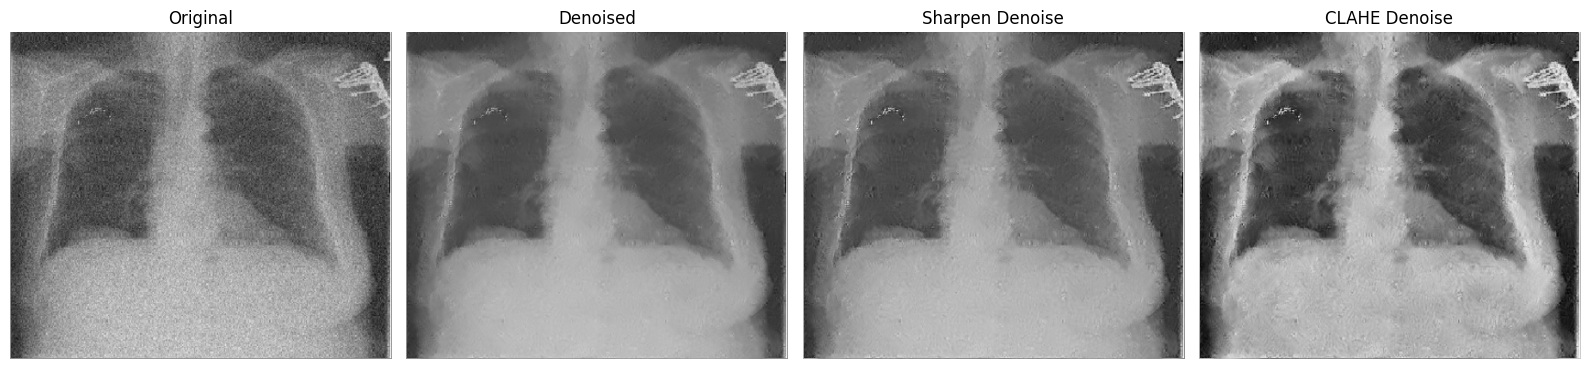

In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img3 = "tugas 3.png"

# Baca gambar sebagai Grayscale
img3_gray = cv2.imread(img3, cv2.IMREAD_GRAYSCALE)

# Denoise (fastNlMeansDenoising)
denoised = cv2.fastNlMeansDenoising(img3_gray, None, h=9, templateWindowSize=7, searchWindowSize=21)

# Sharpened Denoise (Unsharp Masking)
gaussian_blur = cv2.GaussianBlur(denoised, (9, 9), 10.0)
sharpened = cv2.addWeighted(denoised, 1.5, gaussian_blur, -0.5, 0)

# CLAHE (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_denoised = clahe.apply(denoised)

# Hasil
plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1); plt.title("Original"); plt.imshow(img3_gray, cmap="gray"); plt.axis("off")
plt.subplot(1, 4, 2); plt.title("Denoised"); plt.imshow(denoised, cmap="gray"); plt.axis("off")
plt.subplot(1, 4, 3); plt.title("Sharpen Denoise"); plt.imshow(sharpened, cmap="gray"); plt.axis("off")
plt.subplot(1, 4, 4); plt.title("CLAHE Denoise"); plt.imshow(clahe_denoised, cmap="gray"); plt.axis("off")

plt.tight_layout()
plt.show()

# 2. Pembersihan Noise Anotasi

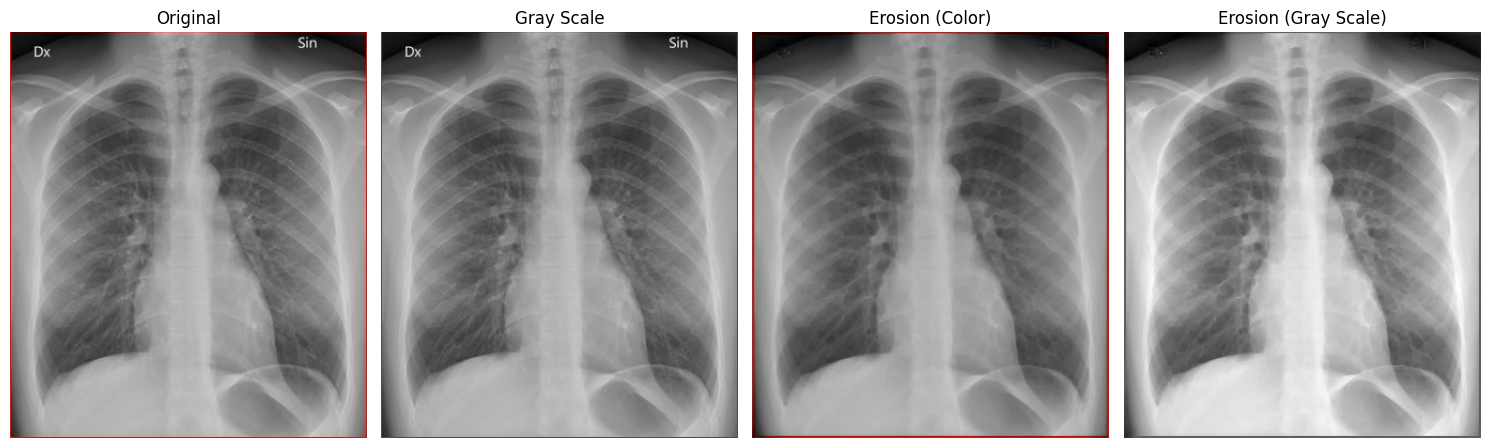

In [61]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img2 = "tugas 2.jpg"

# Baca gambar
img2_bgr = cv2.imread(img2)
img2_rgb = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)

# Metode Erosion
k = np.ones((3, 3), np.uint8)
out = cv2.erode(img2_rgb, k, 1)
out2 = cv2.erode(img_gray, k, 1)

# Plot
plt.figure(figsize=(15,5))

plt.subplot(1,4,1); plt.title("Original"); plt.imshow(img2_rgb); plt.axis("off")
plt.subplot(1,4,2); plt.title("Gray Scale"); plt.imshow(img_gray, cmap="gray"); plt.axis("off")
plt.subplot(1,4,3); plt.title("Erosion (Color)"); plt.imshow(out); plt.axis("off")
plt.subplot(1,4,4); plt.title("Erosion (Gray Scale)"); plt.imshow(out2, cmap="gray"); plt.axis("off")

plt.tight_layout()
plt.show()

# 3. Image Enhancement 

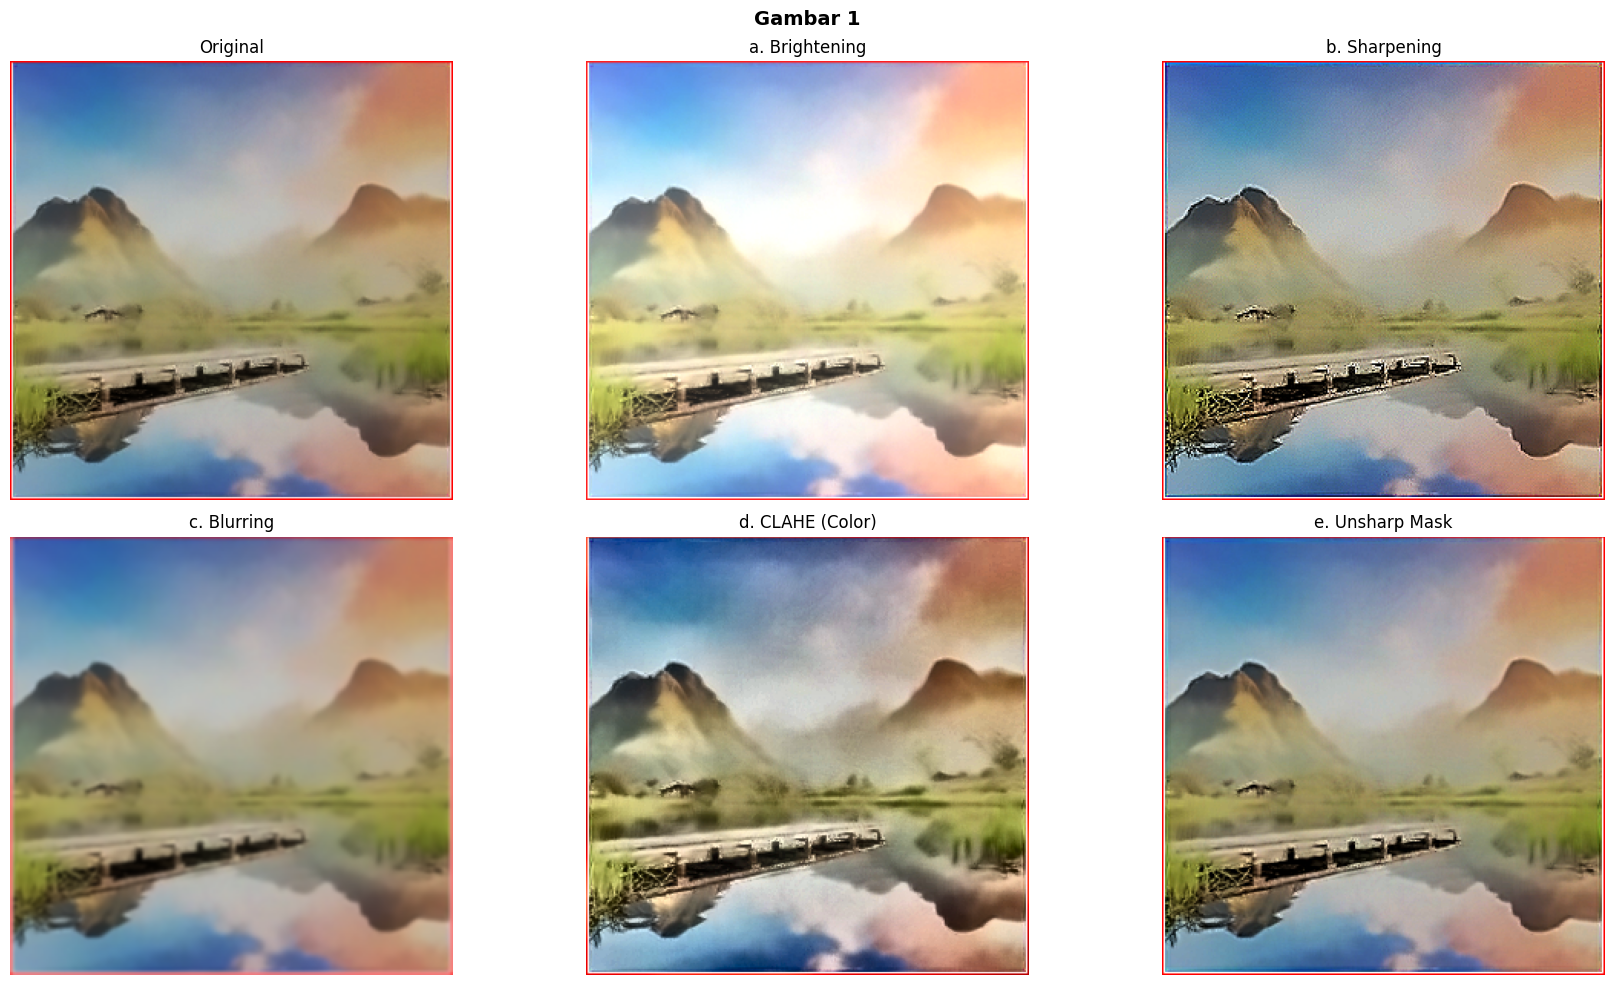

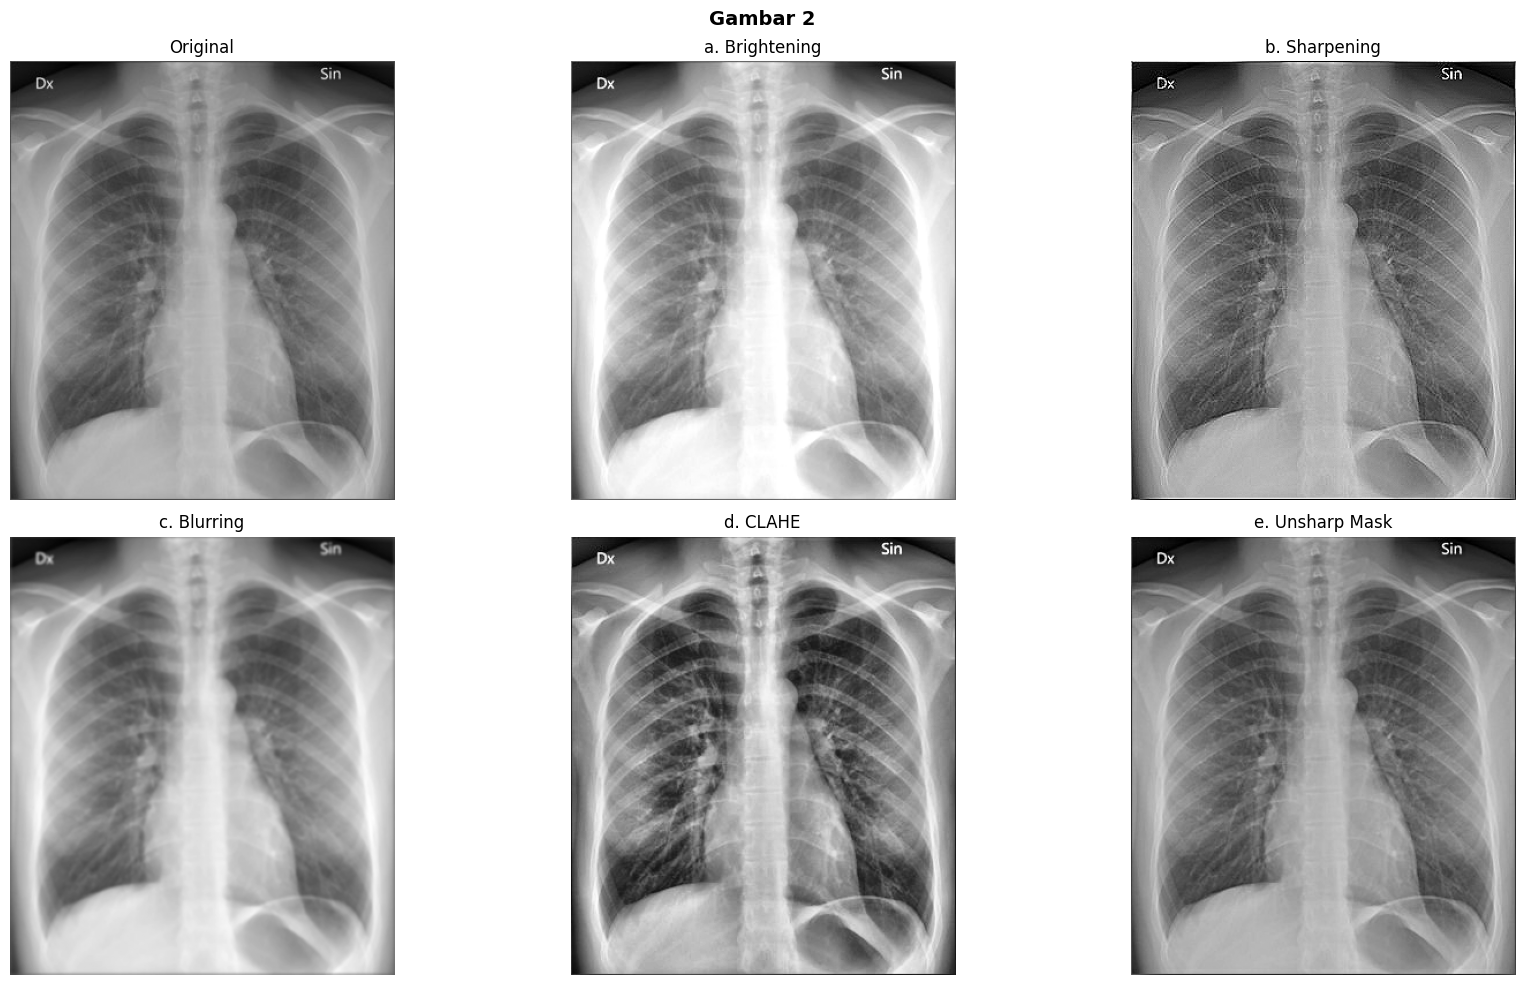

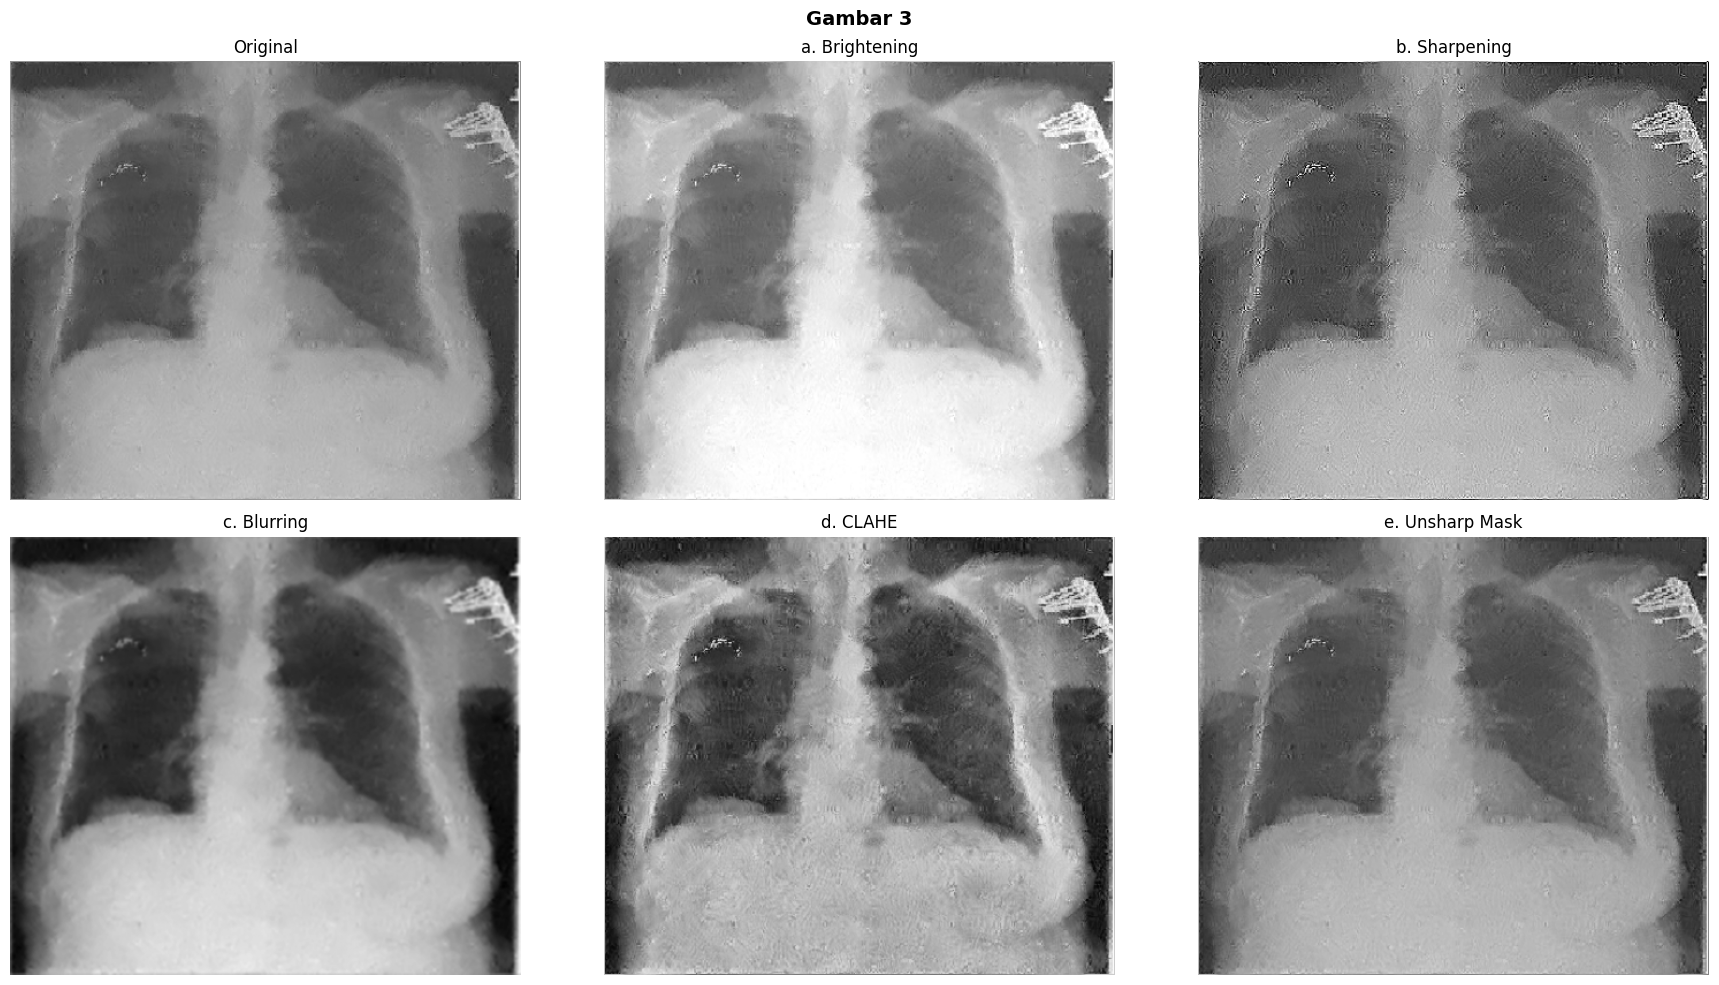

In [62]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def enhance_image(img):
    is_color = (len(img.shape) == 3)
    
    # 1. Brightening (Pencerahan Gambar)
    brightened = cv2.convertScaleAbs(img, alpha=1.2, beta=30)
    
    # 2. Sharpening 
    kernel_sharpen = np.array([[ 0, -1,  0],
                               [-1,  5, -1],
                               [ 0, -1,  0]])
    sharpened = cv2.filter2D(img, -1, kernel_sharpen)
    
    # 3. Blurring
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    
    # 4. CLAHE (Contrast Limited Adaptive Histogram Equalization)
    if is_color:
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge((l_clahe, a, b))
        clahe_enhanced = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
    else:
        clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
        clahe_enhanced = clahe.apply(img)
        
    # 5. Unsharp Masking
    gaussian = cv2.GaussianBlur(img, (9, 9), 10.0)
    unsharp = cv2.addWeighted(img, 1.5, gaussian, -0.5, 0)
    
    return brightened, sharpened, blurred, clahe_enhanced, unsharp

# Load Gambar
img1_rgb = cv2.cvtColor(cv2.imread("tugas 1.png"), cv2.COLOR_BGR2RGB)
img2_gray = cv2.imread("tugas 2.jpg", cv2.IMREAD_GRAYSCALE)
img3_gray = cv2.imread("tugas 3.png", cv2.IMREAD_GRAYSCALE)

# 1. Gambar 1 (Warna): Denoise NLM Colored
img1_nlm = cv2.fastNlMeansDenoisingColored(img1_rgb, None, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21)

# 2. Gambar 2: Grayscale
img2_input = img2_gray

# 3. Gambar 3: Denoised Grayscale
img3_out = cv2.fastNlMeansDenoising(img3_gray, None, h=9, templateWindowSize=7, searchWindowSize=21)

# Terapkan Enhancement (Gambar 1 TETAP WARNA)
b1, s1, bl1, c1, u1 = enhance_image(img1_nlm)
b2, s2, bl2, c2, u2 = enhance_image(img2_input)
b3, s3, bl3, c3, u3 = enhance_image(img3_out)

# gambar 1
plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1)
plt.imshow(img1_nlm)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(b1); plt.title("a. Brightening")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(s1); plt.title("b. Sharpening")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(bl1)
plt.title("c. Blurring")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(c1)
plt.title("d. CLAHE (Color)")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(u1)
plt.title("e. Unsharp Mask")
plt.axis("off")

plt.suptitle("Gambar 1", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Gambar 2
plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1)
plt.imshow(img2_input, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(b2, cmap="gray")
plt.title("a. Brightening")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(s2, cmap="gray")
plt.title("b. Sharpening")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(bl2, cmap="gray")
plt.title("c. Blurring")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(c2, cmap="gray")
plt.title("d. CLAHE")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(u2, cmap="gray")
plt.title("e. Unsharp Mask")
plt.axis("off")

plt.suptitle("Gambar 2", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# gambar 3
plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1)
plt.imshow(img3_out, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(b3, cmap="gray")
plt.title("a. Brightening")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(s3, cmap="gray")
plt.title("b. Sharpening")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(bl3, cmap="gray")
plt.title("c. Blurring")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(c3, cmap="gray")
plt.title("d. CLAHE")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(u3, cmap="gray")
plt.title("e. Unsharp Mask")
plt.axis("off")

plt.suptitle("Gambar 3", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 4. Data Augmentation 

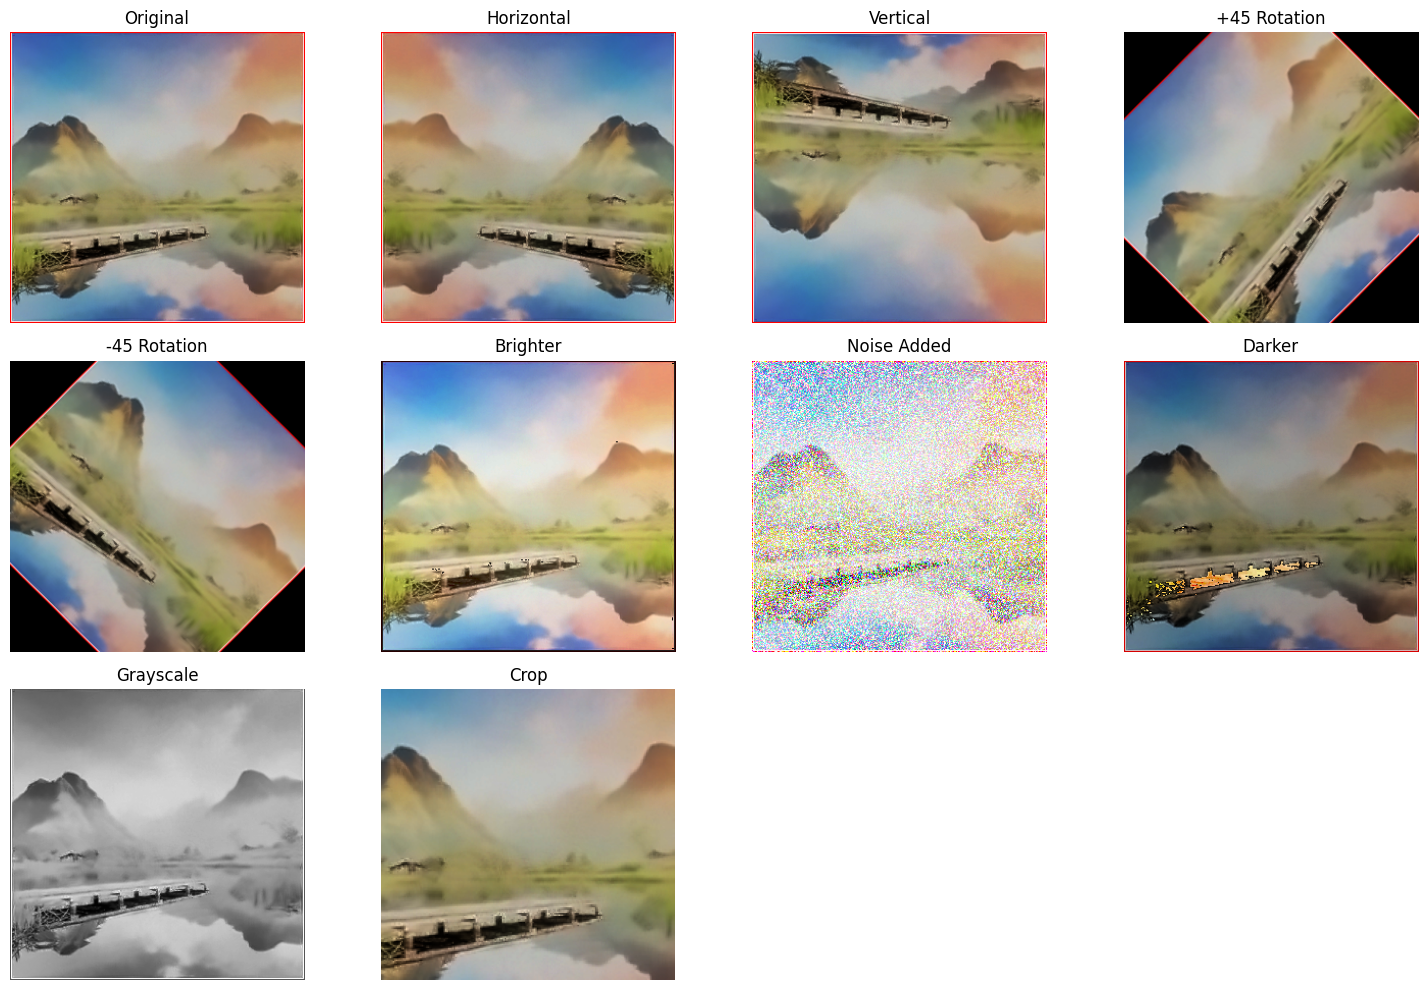

In [63]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def flip_horizontal(image):
    return cv2.flip(image, 1)

def flip_vertical(image):
    return cv2.flip(image, 0)

def rotate(image, angle):
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(image, M, (w, h))

def adjust_brightness(image, value=30):
    if len(image.shape) == 3: # Color image
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        h, s, v = cv2.split(hsv)
        v = np.clip(v + value, 0, 255)
        hsv = cv2.merge((h, s, v))
        return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    else: # Grayscale image
        return np.clip(image + value, 0, 255).astype(np.uint8)

def add_noise(image):
    noise = np.random.normal(0, 25, image.shape).astype(np.uint8)
    noisy = cv2.add(image, noise)
    return noisy

def darker(image, value=30):
    if len(image.shape) == 3: # Color image
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        h, s, v = cv2.split(hsv)
        v = np.clip(v - value, 0, 255)
        hsv = cv2.merge((h, s, v))
        return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    else: # Grayscale image
        return np.clip(image - value, 0, 255).astype(np.uint8)

def grayscale(image):
    if len(image.shape) == 3: # Color image
        return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else: # Already grayscale
        return image

def crop(image, percent=0.85):
    h, w = image.shape[:2]
    new_h, new_w = int(h*percent), int(w*percent)
    start_h, start_w = (h-new_h)//2, (w-new_w)//2
    return image[start_h:start_h+new_h, start_w:start_w+new_w]

def aug(img):
    augmented_images = [
        ("Original", img),
        ("Horizontal", flip_horizontal(img)),
        ("Vertical", flip_vertical(img)),
        ("+45 Rotation", rotate(img, 45)),
        ("-45 Rotation", rotate(img, -45)),
        ("Brighter", adjust_brightness(img, 40)),
        ("Noise Added", add_noise(img)),
        ("Darker", darker(img, 40)),
        ("Grayscale", grayscale(img)),
        ("Crop", crop(img, 0.7))
    ]
    return augmented_images

img1_rgb = cv2.cvtColor(cv2.imread("tugas 1.png"), cv2.COLOR_BGR2RGB)
nlm1_rgb = cv2.fastNlMeansDenoisingColored(img1_rgb, None, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21)

plt.figure(figsize=(15, 10))
for i, (title, aug_img) in enumerate(aug(nlm1_rgb)):
    plt.subplot(3, 4, i+1)
    plt.imshow(aug_img, cmap="gray" if len(aug_img.shape)==2 else None)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()
